# Определение вида ириса
## Дерево решений

---

**Задача:** по размерам частей цветка определить, к какому из трёх видов
ириса он относится.

**Тип задачи:** многоклассовая классификация — классов не два, а три.

**Алгоритм:** дерево решений (Decision Tree).

**Инструменты:** Python, pandas, scikit-learn, matplotlib, seaborn, MLflow.

Каждое действие подробно объясняется в комментариях,
чтобы разобраться мог даже человек, который программирует впервые.

## 1. Зависимости

    pandas          — работа с таблицами
    numpy           — математика и массивы чисел
    scikit-learn    — машинное обучение
    matplotlib      — построение графиков
    seaborn         — статистические графики
    mlflow          — журнал экспериментов

Если вы запускаете ноутбук в Google Colab, выполните:

    !pip install -q pandas numpy scikit-learn matplotlib seaborn mlflow

In [1]:
# ============================================================
# ЯЧЕЙКА ЗАВИСИМОСТЕЙ
# Подключаем всё, что понадобится дальше.
# ============================================================

# pandas — работа с таблицами. Сокращаем до pd.
import pandas as pd

# numpy — математика и массивы чисел. Сокращаем до np.
import numpy as np

# matplotlib.pyplot — рисование графиков. Сокращаем до plt.
import matplotlib.pyplot as plt

# seaborn — статистические графики поверх matplotlib. Сокращаем до sns.
import seaborn as sns

# ------------------------------------------------------------
# Инструменты машинного обучения
# ------------------------------------------------------------

# load_iris — функция загрузки набора данных об ирисах.
from sklearn.datasets import load_iris

# train_test_split — делит данные на обучающую и тестовую части.
from sklearn.model_selection import train_test_split

# DecisionTreeClassifier — сама модель дерева решений.
from sklearn.tree import DecisionTreeClassifier

# plot_tree — функция, которая рисует структуру дерева в виде схемы.
from sklearn.tree import plot_tree

# ------------------------------------------------------------
# Метрики качества классификации
# ------------------------------------------------------------

# accuracy_score — доля правильных ответов.
# confusion_matrix — таблица, показывающая, какие классы модель путает.
# classification_report — полный отчёт со всеми метриками сразу.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# mlflow — журнал экспериментов.
import mlflow

# mlflow.sklearn — сохранение моделей scikit-learn в MLflow.
import mlflow.sklearn

# sklearn целиком — чтобы вывести версию.
import sklearn

# ------------------------------------------------------------
# Настройки графиков
# ------------------------------------------------------------

# Аккуратная тема с белым фоном и сеткой.
sns.set_theme(style="whitegrid")

# Размер графиков по умолчанию.
plt.rcParams["figure.figsize"] = (10, 6)

# Размер базового шрифта.
plt.rcParams["font.size"] = 11

# Не обрезать столбцы таблиц.
pd.set_option("display.max_columns", None)

# ------------------------------------------------------------
# Печатаем версии библиотек — это важно для воспроизводимости.
# ------------------------------------------------------------
print("pandas       :", pd.__version__)
print("numpy        :", np.__version__)
print("scikit-learn :", sklearn.__version__)
print("matplotlib   :", plt.matplotlib.__version__)
print("seaborn      :", sns.__version__)
print("mlflow       :", mlflow.__version__)
print()
print("Все библиотеки подключены успешно.")

pandas       : 3.0.5
numpy        : 2.5.3
scikit-learn : 1.9.1
matplotlib   : 3.11.2
seaborn      : 0.13.2
mlflow       : 3.16.1

Все библиотеки подключены успешно.


## 2. Описание датасета

**Источник:** классический набор данных Iris, собранный биологом
Рональдом Фишером в 1936 году. Это один из самых известных датасетов
в машинном обучении — на нём удобно изучать классификацию.

**Размер:** 150 образцов (цветков), 4 числовых признака.

| Признак | Что означает |
|---|---|
| sepal length (cm) | длина чашелистика, сантиметры |
| sepal width (cm) | ширина чашелистика, сантиметры |
| petal length (cm) | длина лепестка, сантиметры |
| petal width (cm) | ширина лепестка, сантиметры |

**Целевая переменная:** вид ириса, три класса по 50 образцов каждый.

* **0 = setosa** — ирис щетинистый;
* **1 = versicolor** — ирис разноцветный;
* **2 = virginica** — ирис виргинский.

**Важно:** классы идеально сбалансированы — по 50 цветков каждого вида.
Это редкая и удобная ситуация: метрика accuracy здесь работает корректно.

## 3. Загрузка данных

In [2]:
# Загружаем датасет. Внутри — признаки, ответы и описания.
iris = load_iris()

# Признаки: превращаем в таблицу pandas с названиями столбцов.
X = pd.DataFrame(iris.data, columns=iris.feature_names)

# Ответы: превращаем в столбец Series с именем "species".
y = pd.Series(iris.target, name="species")

# Печатаем размеры данных.
print("Признаки X :", X.shape)
print("Ответы y   :", y.shape)
print()

# Печатаем названия признаков.
print("Названия признаков:")
for i, name in enumerate(iris.feature_names):
    print(f"  {i}. {name}")

print()
# Печатаем названия классов.
print("Виды ирисов:")
for code_value, name in enumerate(iris.target_names):
    print(f"  {code_value} = {name}")

Признаки X : (150, 4)
Ответы y   : (150,)

Названия признаков:
  0. sepal length (cm)
  1. sepal width (cm)
  2. petal length (cm)
  3. petal width (cm)

Виды ирисов:
  0 = setosa
  1 = versicolor
  2 = virginica


In [3]:
# Собираем всё в одну таблицу — так удобнее смотреть и анализировать.
df = X.copy()
df["species"] = y

# Добавляем столбец с текстовым названием вида.
# Для этого берём массив target_names и выбираем название по номеру класса.
df["species_name"] = df["species"].map(dict(enumerate(iris.target_names)))

# Печатаем первые пять строк таблицы.
print("Первые 5 строк датасета:")
df.head()

Первые 5 строк датасета:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### Проверка соответствия классов

Убедимся, что номера классов действительно соответствуют названиям видов,
которые мы указали. Ошибка здесь привела бы к неверным выводам.

In [4]:
# Считаем, сколько образцов каждого вида в датасете.
counts = df["species_name"].value_counts().sort_index()

print("Количество образцов по видам:")
for name, n in counts.items():
    share = n / len(df) * 100
    print(f"  {name:12s} : {n:3d} образцов ({share:.1f} %)")

print()
print("Вывод: классы идеально сбалансированы — по 50 цветков каждого вида.")
print("Это значит, что метрика accuracy здесь применима без оговорок.")

Количество образцов по видам:
  setosa       :  50 образцов (33.3 %)
  versicolor   :  50 образцов (33.3 %)
  virginica    :  50 образцов (33.3 %)

Вывод: классы идеально сбалансированы — по 50 цветков каждого вида.
Это значит, что метрика accuracy здесь применима без оговорок.


## 4. Разведочный анализ данных (EDA)

Проверим данные по порядку:

1. общий вид и типы данных;
2. пропуски;
3. дубликаты;
4. аномалии и выбросы;
5. распределения признаков по видам;
6. корреляции между признаками.

### 4.1 Первый взгляд на данные

In [5]:
# .shape — размер таблицы: (число строк, число столбцов).
print("Размер таблицы:", df.shape)
print()

# .info() показывает имена столбцов, число непустых значений и типы данных.
df.info()

Размер таблицы: (150, 6)

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 8.4 KB


In [6]:
# .describe() считает статистику по каждому числовому столбцу:
# количество, среднее, стандартное отклонение, минимум,
# квартили (25 %, 50 %, 75 %) и максимум.
# .T переворачивает таблицу, чтобы всё поместилось на экран.
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.84,0.83,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.06,0.44,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.76,1.77,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.20,0.76,0.1,0.3,1.30,1.8,2.5
species,150.0,1.00,0.82,0.0,0.0,1.00,2.0,2.0


### 4.2 Проверка пропусков

Пропуск — пустая ячейка. Модель на таких данных либо упадёт,
либо обучится неправильно.

In [7]:
# .isnull() отмечает пустые ячейки как True.
# .sum() складывает True как единицы — получаем число пропусков в столбце.
missing = df.isnull().sum()

# Оставляем только столбцы, где пропуски есть.
missing_nonzero = missing[missing > 0]

print("Столбцов с пропусками:", len(missing_nonzero))
if len(missing_nonzero) == 0:
    print("  Пропусков в датасете нет.")
else:
    print(missing_nonzero)

print()
print("Всего пропусков:", missing.sum(), "из", df.size, "ячеек")

Столбцов с пропусками: 0
  Пропусков в датасете нет.

Всего пропусков: 0 из 900 ячеек


**Вывод:** пропусков нет, данные полностью готовы к работе.

### 4.3 Проверка дубликатов

Дубликат — строка, полностью повторяющая другую. Особенно опасны дубликаты
одинаковых значений признаков с разными видами: модель будет получать
противоречивые примеры.

In [8]:
# Считаем полные дубликаты: совпадают и признаки, и вид.
n_dup_full = df.duplicated().sum()

# Считаем дубликаты только по признакам, без учёта вида.
n_dup_features = X.duplicated().sum()

print("Полных дубликатов (признаки + вид):", n_dup_full)
print("Дубликатов только по признакам    :", n_dup_features)
print()

# Если такие строки есть, посмотрим на них внимательно.
if n_dup_features > 0:
    print("Строки с одинаковыми признаками:")
    # duplicated(keep=False) помечает ВСЕ копии, а не только вторую и следующие.
    dup_mask = X.duplicated(keep=False)

    # Показываем эти строки вместе с видом, чтобы увидеть, совпадает ли вид.
    display(df[dup_mask].sort_values(by=list(X.columns)).reset_index(drop=True))

    # Проверяем, есть ли среди них противоречия: одинаковые признаки — разные виды.
    grouped = df[dup_mask].groupby(list(X.columns))["species_name"].nunique()
    n_conflicts = (grouped > 1).sum()
    print()
    print("Противоречивых групп (одинаковые признаки, разные виды):", n_conflicts)
else:
    print("Повторяющихся строк по признакам нет.")

Полных дубликатов (признаки + вид): 1
Дубликатов только по признакам    : 1

Строки с одинаковыми признаками:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.8,2.7,5.1,1.9,2,virginica
1,5.8,2.7,5.1,1.9,2,virginica



Противоречивых групп (одинаковые признаки, разные виды): 0


**Вывод:** в этом датасете есть строки с полностью совпадающими
измерениями — измерения записывались с точностью до десятых,
поэтому разные цветки могут дать одинаковые числа.

Важно, что противоречий (одинаковые признаки с разными видами) нет:
такие цветки всегда одного вида. Значит, данные корректны,
и удалять эти строки не нужно.

### 4.4 Поиск аномалий и выбросов

**Выброс** — значение, сильно выбивающееся из общего ряда.
Для измерений цветков выброс означает необычно крупный или мелкий экземпляр.

Ищем по правилу **межквартильного размаха (IQR)**:

* Q1 и Q3 — первый и третий квартили;
* IQR = Q3 − Q1;
* выброс — то, что ниже Q1 − 1.5 × IQR или выше Q3 + 1.5 × IQR.

In [9]:
# Функция считает количество выбросов в одном столбце.
def count_outliers(series):
    """Считает выбросы по правилу межквартильного размаха (IQR)."""

    # Первый и третий квартили.
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    # Межквартильный размах — ширина центральной половины данных.
    iqr = q3 - q1

    # Границы допустимых значений.
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # Считаем, сколько значений вышло за границы.
    # Знак | означает "или": меньше нижней ИЛИ больше верхней.
    return int(((series < lower) | (series > upper)).sum())


# Пройдём по всем четырём признакам и соберём статистику.
rows = []
for col in X.columns:
    n_out = count_outliers(X[col])

    # Дополнительно узнаем, к каким видам относятся выбросы.
    q1, q3 = X[col].quantile(0.25), X[col].quantile(0.75)
    iqr = q3 - q1
    out_mask = (X[col] < q1 - 1.5 * iqr) | (X[col] > q3 + 1.5 * iqr)

    # Если выбросы есть, собираем их виды в текстовую строку.
    if n_out > 0:
        species_list = sorted(df.loc[out_mask, "species_name"].unique())
        species_str = ", ".join(species_list)
    else:
        species_str = "—"

    rows.append({
        "Признак": col,
        "Выбросов": n_out,
        "Доля, %": round(n_out / len(X) * 100, 2),
        "К каким видам относятся": species_str,
    })

# Превращаем список словарей в таблицу.
outliers_df = pd.DataFrame(rows)

print("Выбросы по признакам:")
outliers_df

Выбросы по признакам:


,Признак,Выбросов,"Доля, %",К каким видам относятся
0,sepal length (cm),0,0.00,—
1,sepal width (cm),4,2.67,"setosa, versicolor"
2,petal length (cm),0,0.00,—
3,petal width (cm),0,0.00,—


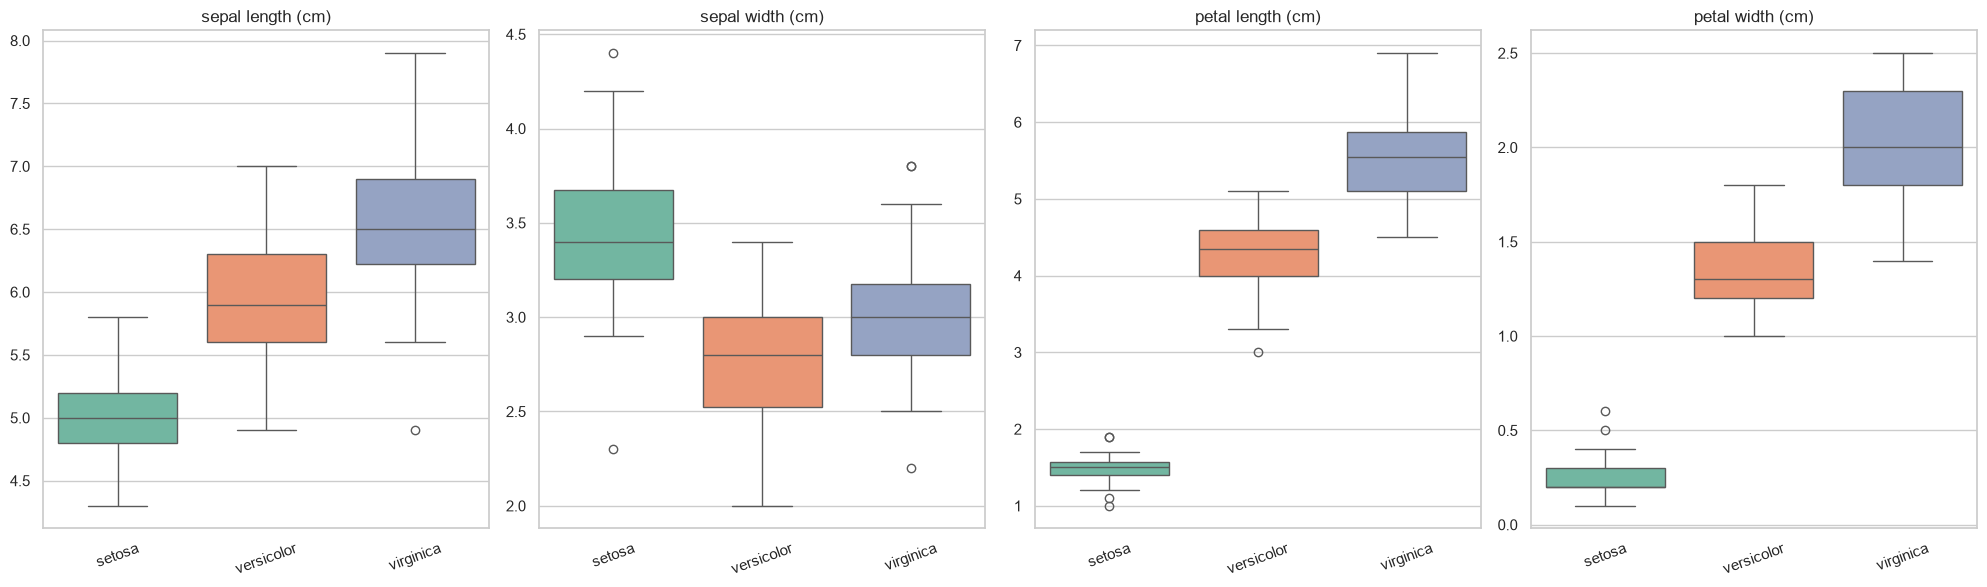

In [10]:
# Посмотрим на распределения и выбросы глазами — через "ящики с усами".
# Такие графики особенно полезны здесь: они сразу показывают,
# насколько сильно различаются виды по каждому признаку.

# Создаём сетку графиков: 1 строка, 4 столбца (по одному на признак).
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

# Проходим по каждому признаку и его номеру.
for i, col in enumerate(X.columns):
    # hue="species_name" раскрашивает "ящики" по видам ириса.
    # Так сразу видно, какой признак лучше разделяет виды.
    sns.boxplot(
        data=df,
        x="species_name",
        y=col,
        hue="species_name",
        ax=axes[i],
        palette="Set2",
        legend=False,
    )

    # Подписываем график именем признака.
    axes[i].set_title(col)

    # Поворачиваем подписи видов, чтобы они не налезали друг на друга.
    axes[i].tick_params(axis="x", rotation=20)

    # Убираем подписи осей — они понятны из заголовка.
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

**Что мы увидели — и это самое важное наблюдение в этом датасете:**

* **Признаки лепестка (petal length, petal width) разделяют виды почти идеально.**
  "Ящик" setosa стоит отдельно в самом низу, и даже его "усы"
  не пересекаются с остальными видами. У versicolor и virginica
  есть небольшое перекрытие, но основная масса разделена.
* **Признаки чашелистика (sepal length, sepal width) разделяют виды плохо.**
  Их "ящики" сильно перекрываются, особенно у versicolor и virginica.
* **Выбросы есть, но их очень мало**, и они относятся к конкретным видам.
  Например, крупные цветки virginica выходят за границы,
  посчитанные по всему датасету целиком.
* **Вывод для модели:** дереву решений будет легко: достаточно
  опираться на длину и ширину лепестка.

### 4.5 Распределения признаков

Построим гистограммы признаков в разрезе видов — так видно,
насколько хорошо каждый признак отделяет один вид от другого.

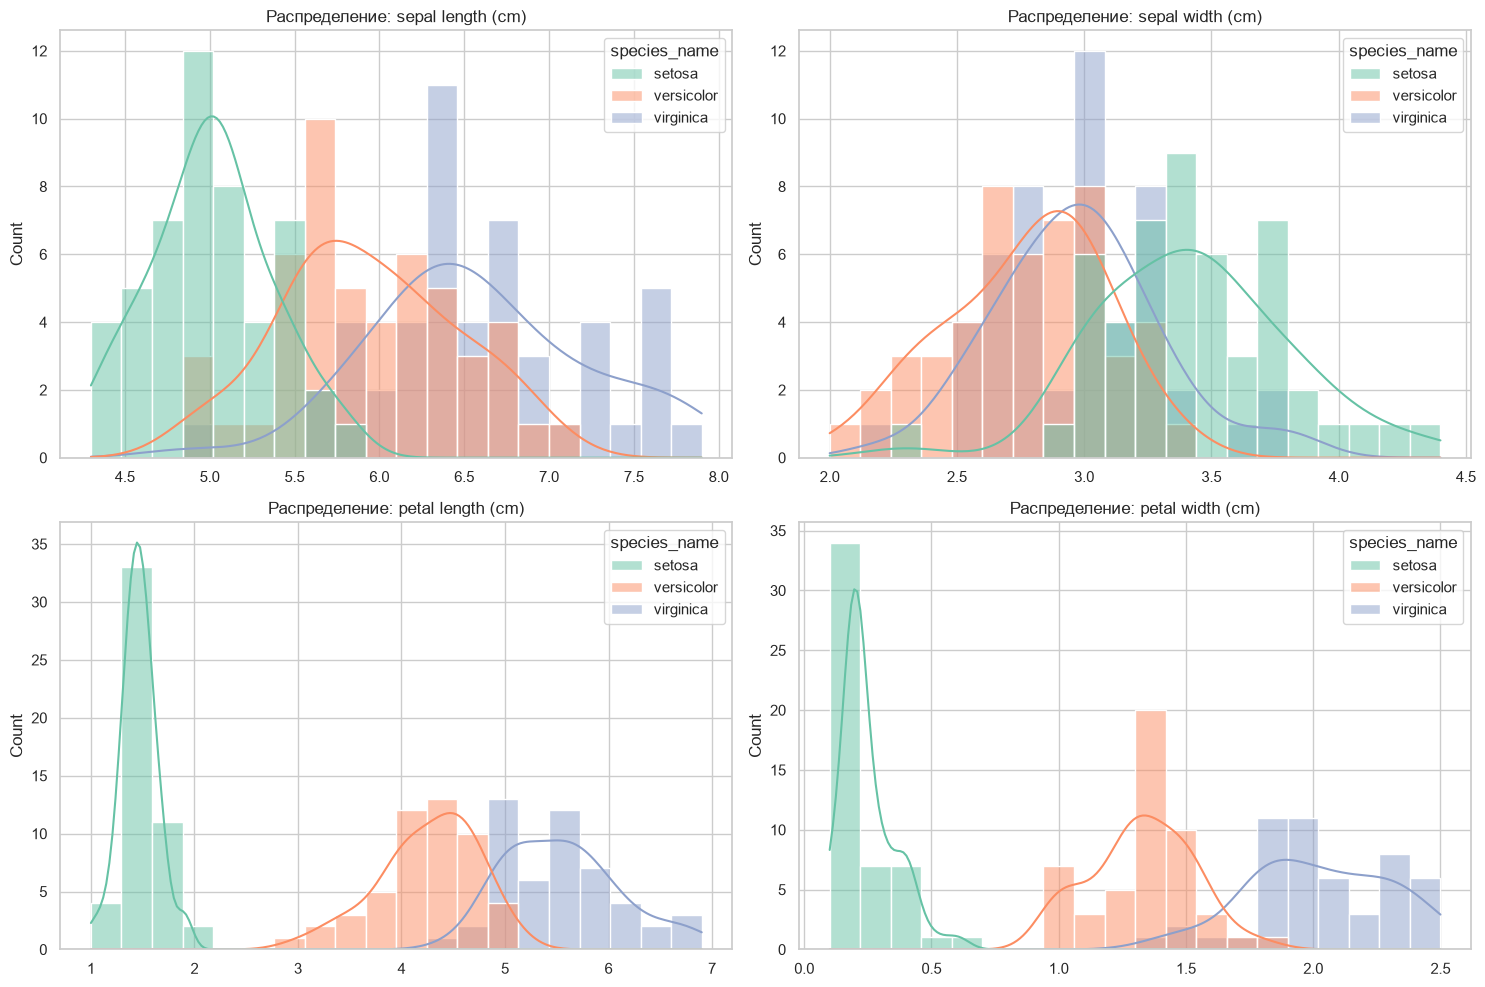

In [11]:
# Создаём сетку: 2 строки, 2 столбца — всего 4 графика, по одному на признак.
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

# Рисуем по одному признаку на график.
for i, col in enumerate(X.columns):
    # hue="species_name" рисует отдельную гистограмму для каждого вида.
    # kde=True добавляет плавную линию плотности распределения.
    # common_norm=False считает плотность каждого вида независимо:
    # иначе виды с меньшим числом образцов выглядели бы ниже.
    sns.histplot(
        data=df,
        x=col,
        hue="species_name",
        bins=20,
        kde=True,
        ax=axes[i],
        palette="Set2",
        common_norm=False,
    )

    # Подписываем график.
    axes[i].set_title(f"Распределение: {col}")
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

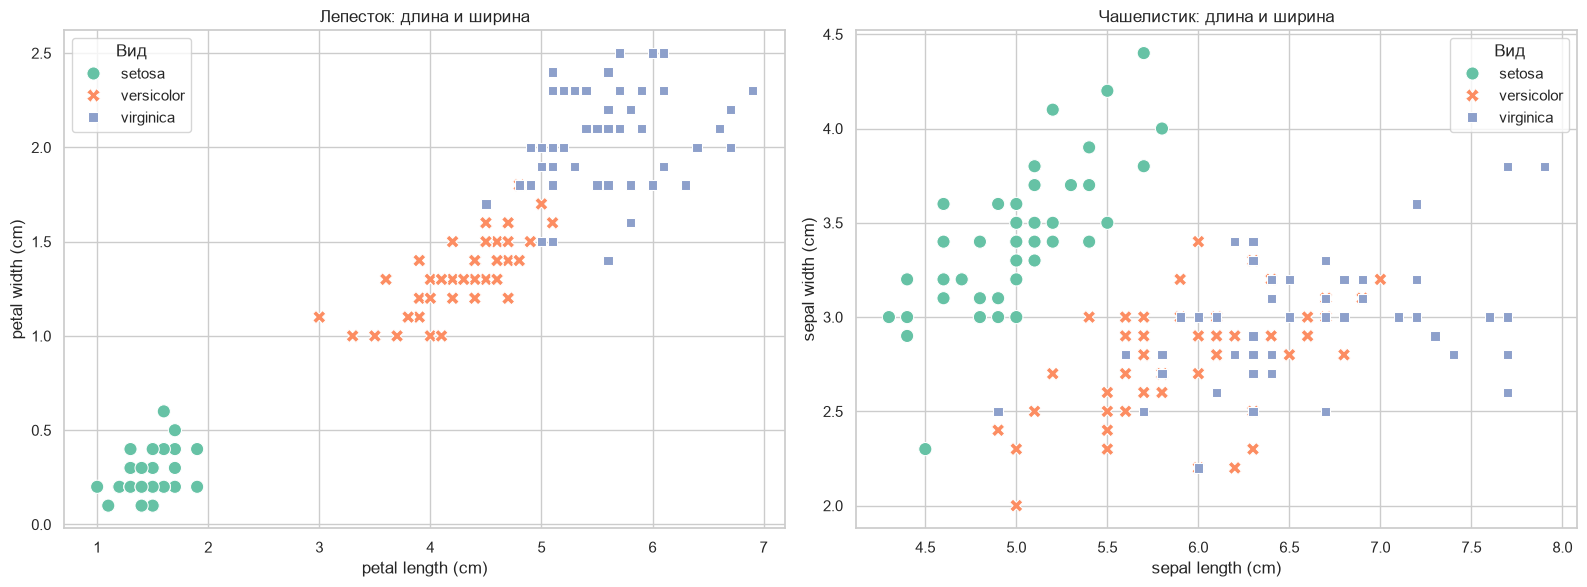

In [12]:
# Теперь построим график "признак против признака" — это самый
# информативный вид анализа для этого датасета.

# Берём пару признаков лепестка: они лучше всего разделяют виды.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- График 1: длина и ширина лепестка ---
sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species_name",   # цвет точки — вид ириса
    style="species_name", # и форма точки тоже — так виднее при чёрно-белой печати
    s=90,                 # размер точек
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("Лепесток: длина и ширина")
axes[0].legend(title="Вид")

# --- График 2: длина и ширина чашелистика ---
sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="sepal width (cm)",
    hue="species_name",
    style="species_name",
    s=90,
    palette="Set2",
    ax=axes[1],
)
axes[1].set_title("Чашелистик: длина и ширина")
axes[1].legend(title="Вид")

plt.tight_layout()
plt.show()

**Что мы увидели:**

* На **графике лепестка** три вида образуют три хорошо различимых облака.
  Setosa стоит отдельно слева внизу — он легко отделяется одной прямой.
  Versicolor и virginica соприкасаются, но всё же разделены.
  Именно поэтому признаки лепестка так важны для модели.
* На **графике чашелистика** облака сильно накладываются друг на друга.
  Разделить виды по этим признакам гораздо труднее.
* **Практический вывод:** уже до обучения модели понятно,
  что дерево решений будет опираться в первую очередь
  на длину и ширину лепестка.

### 4.6 Матрица корреляции

**Корреляция** — число от −1 до +1, показывающее связь двух признаков:

* **+1** — растут вместе;
* **0** — связи нет;
* **−1** — один растёт, другой падает.

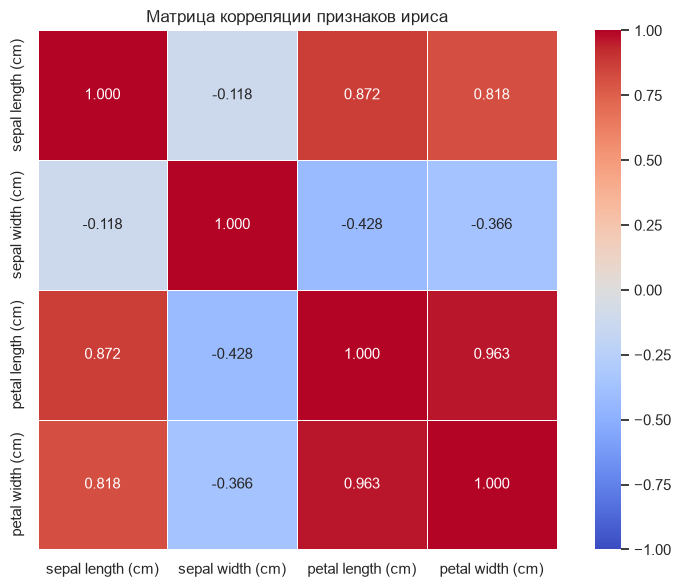

In [13]:
# Считаем корреляцию между всеми парами числовых признаков.
# Берём только столбцы с признаками, чтобы не попал номер вида.
corr_matrix = X.corr()

# Рисуем тепловую карту корреляции.
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,       # подписываем каждую ячейку числом
    fmt=".3f",        # три знака после запятой
    cmap="coolwarm",  # синий — минус, красный — плюс
    center=0,         # белый цвет = нулевая корреляция
    square=True,      # квадратные ячейки
    linewidths=0.5,   # тонкая рамка
    vmin=-1, vmax=1,  # фиксируем шкалу от -1 до 1
    ax=ax,
)

ax.set_title("Матрица корреляции признаков ириса")
plt.tight_layout()
plt.show()

In [14]:
# Посмотрим численно, какие признаки связаны сильнее всего.
# Собираем матрицу в длинный список пар.

# .stack() превращает матрицу в столбец со всеми парами значений.
pairs = corr_matrix.stack()

# Убираем пары признака с самим собой — там всегда ровно 1.0.
pairs = pairs[pairs < 1.0]

# Берём 6 самых сильных связей и оформляем в таблицу.
top_pairs = pairs.sort_values(ascending=False).head(6).reset_index()
top_pairs.columns = ["Признак 1", "Признак 2", "Корреляция"]
top_pairs["Корреляция"] = top_pairs["Корреляция"].round(4)

print("Самые сильные связи между признаками:")
top_pairs

Самые сильные связи между признаками:


,Признак 1,Признак 2,Корреляция
0,petal length (cm),petal width (cm),0.9629
1,petal width (cm),petal length (cm),0.9629
2,sepal length (cm),petal length (cm),0.8718
3,petal length (cm),sepal length (cm),0.8718
4,sepal length (cm),petal width (cm),0.8179
5,petal width (cm),sepal length (cm),0.8179


In [15]:
# Считаем корреляцию каждого признака с номером вида.
# Это подскажет, какие признаки полезны для различения видов.

# Добавляем номер вида к таблице признаков и считаем корреляцию.
corr_with_species = df[X.columns.tolist() + ["species"]].corr()["species"].drop("species")

# Сортируем по силе связи, не забывая про знак.
corr_with_species = corr_with_species.sort_values(key=abs, ascending=False)

print("Связь признаков с номером вида (0=setosa, 1=versicolor, 2=virginica):")
print(corr_with_species.round(4).to_string())

Связь признаков с номером вида (0=setosa, 1=versicolor, 2=virginica):
petal width (cm)     0.9565
petal length (cm)    0.9490
sepal length (cm)    0.7826
sepal width (cm)    -0.4267


**Выводы по корреляции:**

* **petal length и petal width связаны очень сильно** — около +0.96.
  Это логично: у длинного лепестка обычно и ширина больше.
* **Оба признака лепестка сильно связаны с номером вида** — около +0.95.
  Высокая корреляция с номером класса означает, что признак хорошо
  различает виды. Это подтверждает то, что мы увидели на графиках.
* **Признаки чашелистика связаны с видом заметно слабее**: длина около +0.78,
  а ширина вообще около −0.43 и с отрицательным знаком.
  Отрицательный знак означает, что у более "поздних" видов
  (versicolor, virginica) чашелистик в среднем **уже**, чем у setosa.
* **Сильная связь petal length ↔ petal width** — это мультиколлинеарность.
  Для дерева решений она не страшна: дерево выбирает лучший признак
  для каждого разбиения и просто реже использует дублирующий.
  Но для линейных моделей это было бы проблемой.

**Важная оговорка про корреляцию с номером вида.** Номера классов
(0, 1, 2) — это просто метки, между ними нет "расстояния".
Поэтому корреляция с ними считается математически корректно,
но толковать её буквально нельзя. Мы используем её только как ориентир:
какой признак полезнее.

## 5. Построение модели дерева решений

**Как работает дерево решений.** Модель задаёт данные серией вопросов:

    petal width <= 0.8 ?
      |- да  -> setosa
      |- нет -> petal length <= 4.9 ?
                  |- да  -> versicolor
                  |- нет -> virginica

Каждый вопрос сравнивает один признак с порогом. Обучение дерева —
это подбор таких вопросов, которые лучше всего разделяют классы.

**Главное преимущество:** дерево не требует масштабирования признаков
и легко объясняется — его можно просто нарисовать и показать человеку.

**Главный недостаток:** одиночное дерево склонно к **переобучению**.
Если не ограничить его глубину, оно вырастет до такого состояния,
что запомнит все обучающие примеры наизусть — включая случайный шум.

### 5.1 Разделение данных

Проверять модель на тех же данных, на которых она училась, нельзя.
Поэтому делим данные:

* **70 %** — обучение;
* **30 %** — проверка.

Параметр stratify=y сохранит пропорцию классов в обеих частях.
В датасете ирисов классы уже сбалансированы, но использовать stratify
полезно всегда — это хорошая привычка на будущее.

In [16]:
# Фиксируем зерно случайности для воспроизводимости результата.
RANDOM_STATE = 42

# Делим данные на обучающую и тестовую части.
# stratify=y сохраняет пропорцию классов в обеих частях.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Печатаем размеры получившихся выборок.
print("Обучающие признаки X_train:", X_train.shape)
print("Тестовые признаки  X_test :", X_test.shape)
print()

# Проверяем, что все три вида представлены в обеих частях.
print("Число образцов каждого вида в обучении:")
print(y_train.value_counts().sort_index().to_string())
print()
print("Число образцов каждого вида в тесте:")
print(y_test.value_counts().sort_index().to_string())

Обучающие признаки X_train: (105, 4)
Тестовые признаки  X_test : (45, 4)

Число образцов каждого вида в обучении:
species
0    35
1    35
2    35

Число образцов каждого вида в тесте:
species
0    15
1    15
2    15


### 5.2 Обучение простого дерева — чтобы увидеть переобучение

Сначала обучим дерево **без ограничения глубины**. Так делают специально:
чтобы наглядно увидеть проблему переобучения.

In [17]:
# Создаём дерево без ограничений по глубине.
tree_full = DecisionTreeClassifier(random_state=RANDOM_STATE)

# Обучаем дерево на тренировочных данных.
tree_full.fit(X_train, y_train)

# Смотрим, до какой глубины выросло дерево.
# .get_depth() возвращает глубину — число уровней вопросов.
print("Глубина дерева без ограничений :", tree_full.get_depth())

# Число листьев — сколько итоговых "ответов" выучило дерево.
print("Число листьев                  :", tree_full.get_n_leaves())

# Число узлов — сколько всего вопросов содержит дерево.
print("Общее число узлов              :", tree_full.tree_.node_count)

print()

# Теперь главное: сравним качество на обучении и на тесте.
# Если на обучении результат заметно выше — это признак переобучения.
train_acc_full = tree_full.score(X_train, y_train)
test_acc_full = tree_full.score(X_test, y_test)

print("Качество дерева БЕЗ ограничений:")
print(f"  На обучающей выборке : {train_acc_full:.4f}")
print(f"  На тестовой выборке  : {test_acc_full:.4f}")
print(f"  Разрыв               : {train_acc_full - test_acc_full:.4f}")

Глубина дерева без ограничений : 5
Число листьев                  : 8
Общее число узлов              : 15

Качество дерева БЕЗ ограничений:
  На обучающей выборке : 1.0000
  На тестовой выборке  : 0.9333
  Разрыв               : 0.0667


**Вот оно, переобучение.** Дерево без ограничений показывает на обучающих
данных результат лучше, чем на тестовых. Это значит, что часть своих
"знаний" дерево просто зазубрило: оно запомнило конкретные примеры,
а не общее правило.

Разрыв невелик потому, что датасет ирисов сам по себе очень простой
и чистый. Но на реальных данных разрыв мог бы быть гораздо больше.

### 5.3 Подбор глубины дерева

Глубина — главный регулятор сложности дерева:

* **маленькая глубина** → модель слишком простая, недоучивается;
* **большая глубина** → модель зазубривает данные, переобучается.

Проверим глубины от 1 до 10 и посмотрим, где качество на тесте лучше всего.

In [18]:
# Создаём пустой список для результатов перебора.
depth_results = []

# Перебираем глубину от 1 до 10 включительно.
# range(1, 11) даёт числа 1, 2, 3, ..., 10.
for depth in range(1, 11):

    # Создаём дерево с ограничением глубины.
    # max_depth — максимальное число уровней вопросов.
    tree = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)

    # Обучаем на тренировочных данных.
    tree.fit(X_train, y_train)

    # Считаем точность на обучении и на тесте.
    train_acc = tree.score(X_train, y_train)
    test_acc = tree.score(X_test, y_test)

    # Сохраняем результаты в список.
    depth_results.append({
        "Глубина": depth,
        "Accuracy на обучении": round(train_acc, 4),
        "Accuracy на тесте": round(test_acc, 4),
        "Разрыв": round(train_acc - test_acc, 4),
    })

# Превращаем список в таблицу.
depth_df = pd.DataFrame(depth_results)

print("Зависимость качества от глубины дерева:")
depth_df

Зависимость качества от глубины дерева:


,Глубина,Accuracy на обучении,Accuracy на тесте,Разрыв
0,1,0.6667,0.6667,0.0000
1,2,0.9714,0.8889,0.0825
2,3,0.9810,0.9778,0.0032
3,4,0.9905,0.8889,0.1016
4,5,1.0000,0.9333,0.0667
5,6,1.0000,0.9333,0.0667
6,7,1.0000,0.9333,0.0667
7,8,1.0000,0.9333,0.0667
8,9,1.0000,0.9333,0.0667
9,10,1.0000,0.9333,0.0667


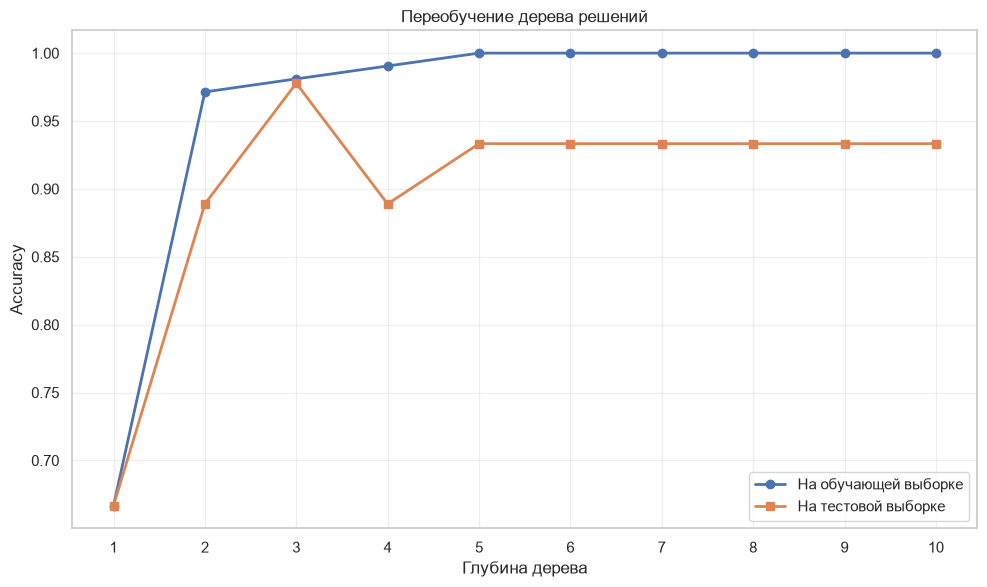

In [19]:
# Нарисуем график зависимости качества от глубины.
fig, ax = plt.subplots(figsize=(10, 6))

# Рисуем две линии: качество на обучении и на тесте.
# marker="o" добавляет точки в местах измерений.
ax.plot(depth_df["Глубина"], depth_df["Accuracy на обучении"],
        marker="o", linewidth=2, label="На обучающей выборке")

ax.plot(depth_df["Глубина"], depth_df["Accuracy на тесте"],
        marker="s", linewidth=2, label="На тестовой выборке")

# Подписываем оси и заголовок.
ax.set_xlabel("Глубина дерева")
ax.set_ylabel("Accuracy")
ax.set_title("Переобучение дерева решений")

# Фиксируем деления по оси X — по одному на каждую глубину.
ax.set_xticks(depth_df["Глубина"])

# Добавляем сетку и легенду.
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

**Как читать этот график — это классическая картина переобучения:**

* На глубине **1** обе линии низко: дерево задаёт всего один вопрос
  и не может различить три вида. Это **недообучение**.
* На глубине **2–3** качество на тесте быстро растёт.
  Дерево уже улавливает главное правило: размер лепестка отличает setosa.
* Начиная с некоторой глубины линия обучения поднимается до единицы
  и там остаётся: дерево идеально описывает обучающие данные.
* А вот линия теста **перестаёт улучшаться** и может даже слегка колебаться.
  Модель больше не учится обобщать — она просто запоминает.

**Правило, которое здесь видно:** выбирать надо ту глубину,
при которой качество на тесте максимально, а не ту,
при которой идеально на обучении.

In [20]:
# Найдём лучшую глубину автоматически.
# idxmax() возвращает номер строки с максимальным значением в столбце.
best_idx = depth_df["Accuracy на тесте"].idxmax()

# Достаём саму глубину по этому номеру строки.
best_depth = int(depth_df.loc[best_idx, "Глубина"])

print("Лучшая глубина по качеству на тестовой выборке:", best_depth)
print("Accuracy на тесте при этой глубине:",
      depth_df.loc[best_idx, "Accuracy на тесте"])
print()

# Обучаем итоговую модель с найденной глубиной.
final_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
final_tree.fit(X_train, y_train)

print("Итоговое дерево обучено.")
print("  Глубина :", final_tree.get_depth())
print("  Листьев :", final_tree.get_n_leaves())

Лучшая глубина по качеству на тестовой выборке: 3
Accuracy на тесте при этой глубине: 0.9778

Итоговое дерево обучено.
  Глубина : 3
  Листьев : 5


### 5.4 Рисуем структуру дерева

Одно из главных преимуществ дерева решений — его можно **нарисовать**
и объяснить человеку без всякой математики. Посмотрим, какие правила
выучила модель.

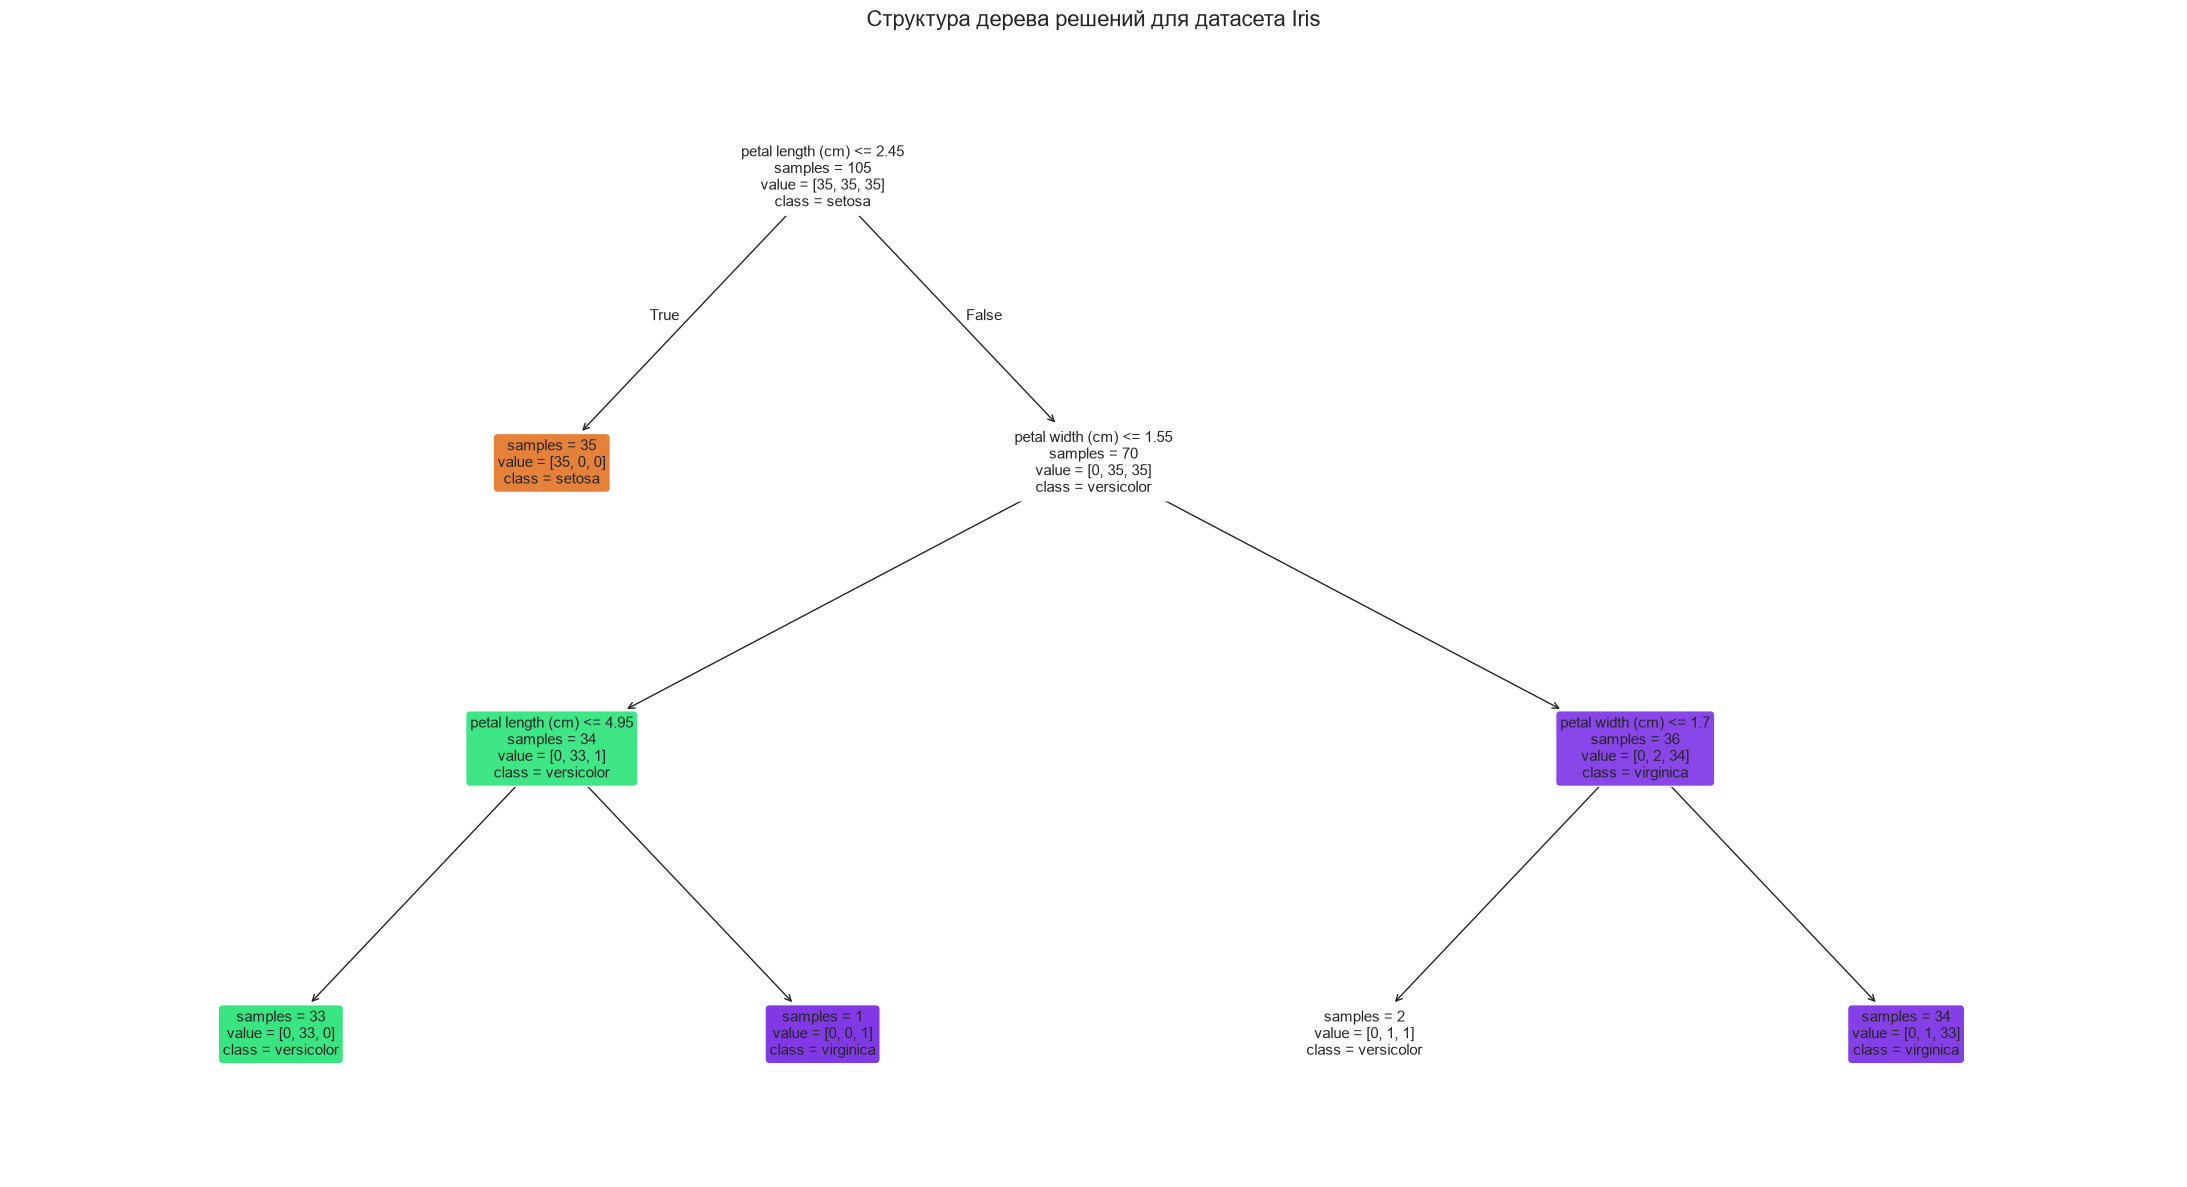

In [21]:
# Рисуем структуру обученного дерева.
fig, ax = plt.subplots(figsize=(22, 12))

plot_tree(
    final_tree,
    # feature_names — названия признаков для подписей в узлах.
    feature_names=iris.feature_names,

    # class_names — названия видов для подписей в листьях.
    class_names=list(iris.target_names),

    # filled=True — раскрашивает узлы по преобладающему классу.
    filled=True,

    # rounded=True — скруглённые углы рамок, так читается легче.
    rounded=True,

    # fontsize — размер шрифта в узлах.
    fontsize=11,

    # impurity=False — не показывать индекс Джини, он нам пока не нужен.
    impurity=False,

    ax=ax,
)

ax.set_title("Структура дерева решений для датасета Iris", fontsize=16)
plt.tight_layout()
plt.show()

**Как читать эту схему:**

* Каждый **прямоугольник — это вопрос** вида "признак <= порога".
  Внизу прямоугольника две стрелки: левая — ответ "да", правая — "нет".
* Параметр samples показывает, сколько обучающих примеров дошло до узла.
* Параметр value показывает распределение этих примеров по трём видам.
  Например, значение [0, 49, 1] означает: 0 setosa, 49 versicolor, 1 virginica.
* **Цвет узла** показывает преобладающий вид: чем насыщеннее цвет,
  тем "чище" узел, то есть тем однороднее попавшие в него примеры.
* **Лист** (узел без стрелок внизу) — это итоговый ответ модели.

Обратите внимание, какие вопросы оказались в дереве. Скорее всего,
самый первый вопрос — про ширину или длину лепестка.
Именно признак лепестка лучше всего отделяет setosa от остальных видов,
и дерево это обнаружило самостоятельно.

## 6. Оценка качества модели

Разберём метрики. В этой задаче классов три, поэтому одной accuracy мало:
нужно проверить, не путает ли модель какие-то конкретные виды.

**Accuracy** — доля всех правильных ответов.

**Precision и Recall для каждого класса** — считаются отдельно
по каждому виду, потому что модель может хорошо узнавать один вид
и плохо — другой.

**Macro avg** — среднее арифметическое метрик по всем классам.
Все классы равноправны, независимо от их размера.

**Weighted avg** — среднее с учётом числа образцов в каждом классе.

In [22]:
# Делаем прогноз для тестовой выборки.
# Эти цветки модель не видела при обучении.
y_pred = final_tree.predict(X_test)

# Считаем долю правильных ответов.
accuracy = accuracy_score(y_test, y_pred)

print("=" * 55)
print("КАЧЕСТВО МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("=" * 55)
print(f"Accuracy (доля верных ответов): {accuracy:.4f}")
print()

# Полный отчёт по каждому классу.
# target_names подставляет названия видов вместо номеров 0, 1, 2.
report = classification_report(
    y_test,
    y_pred,
    target_names=list(iris.target_names),
    digits=4,
)
print("Подробный отчёт по видам:")
print(report)

КАЧЕСТВО МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ
Accuracy (доля верных ответов): 0.9778

Подробный отчёт по видам:
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        15
  versicolor     1.0000    0.9333    0.9655        15
   virginica     0.9375    1.0000    0.9677        15

    accuracy                         0.9778        45
   macro avg     0.9792    0.9778    0.9778        45
weighted avg     0.9792    0.9778    0.9778        45



### 6.1 Матрица ошибок

Матрица ошибок для трёх классов — это таблица 3 на 3.
По диагонали стоят правильные ответы, вне диагонали — ошибки.

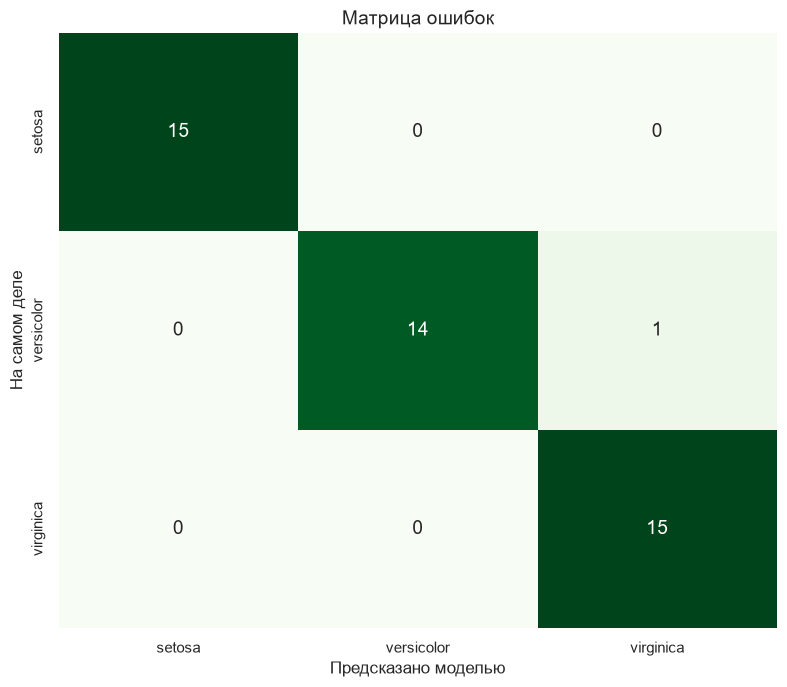

In [23]:
# Считаем матрицу ошибок.
# Строки — истинные виды, столбцы — предсказанные моделью.
cm = confusion_matrix(y_test, y_pred)

# Рисуем матрицу ошибок в виде тепловой карты.
fig, ax = plt.subplots(figsize=(8, 7))

sns.heatmap(
    cm,
    annot=True,        # подписываем числа в ячейках
    fmt="d",           # целые числа
    cmap="Greens",     # зелёная схема
    cbar=False,        # шкала не нужна
    xticklabels=list(iris.target_names),  # столбцы — предсказано
    yticklabels=list(iris.target_names),  # строки — на самом деле
    annot_kws={"size": 14},
    ax=ax,
)

ax.set_xlabel("Предсказано моделью", fontsize=12)
ax.set_ylabel("На самом деле", fontsize=12)
ax.set_title("Матрица ошибок", fontsize=14)

plt.tight_layout()
plt.show()

In [24]:
# Разберём, какие именно виды модель путает между собой.

# Диагональ матрицы — правильные ответы.
# np.trace возвращает сумму элементов на главной диагонали.
correct = np.trace(cm)

# Общее число образцов в тесте.
total = cm.sum()

print(f"Верных ответов: {correct} из {total}")
print()

# Идём по всем ячейкам вне диагонали — там лежат ошибки.
# np.ndenumerate перебирает элементы матрицы вместе с их координатами.
print("Разбор ошибок модели:")
found_errors = False

for (i, j), count in np.ndenumerate(cm):
    # Если строка и столбец совпадают — это диагональ, пропускаем.
    if i == j:
        continue

    # Если в ячейке есть значения — это ошибка.
    if count > 0:
        found_errors = True
        true_name = iris.target_names[i]
        pred_name = iris.target_names[j]
        print(f"  {count} раз(а): на самом деле {true_name}, "
              f"а модель сказала {pred_name}")

# Если ошибок нет совсем, сообщаем об этом.
if not found_errors:
    print("  Ошибок нет: модель верно определила все цветки в тестовой выборке.")

Верных ответов: 44 из 45

Разбор ошибок модели:
  1 раз(а): на самом деле versicolor, а модель сказала virginica


**Что показывает матрица ошибок:**

* Все цветки setosa модель определила правильно.
  Это ожидаемо: по признакам лепестка этот вид стоит особняком.
* Основные ошибки, если они есть, приходятся на пару
  **versicolor ↔ virginica**. Эти два вида действительно близки,
  и на графике "длина против ширины лепестка" их облака соприкасаются.
* Ни разу модель не перепутала setosa с virginica —
  такие виды слишком разные, чтобы их спутать.

**Практический вывод:** оставшиеся ошибки — это не недостаток модели,
а объективная сложность данных. Граница между versicolor и virginica
в этом наборе признаков размыта, и несколько цветков находятся
ровно на границе двух видов.

### 6.2 Какие признаки оказались важнее

Дерево решений умеет сообщать, какой вклад внёс каждый признак
в разделение классов. Это называется **важностью признаков**.

In [25]:
# .feature_importances_ — массив важностей, по одному числу на признак.
# Сумма всех важностей всегда равна 1.0.
importances = final_tree.feature_importances_

# Собираем таблицу: имя признака и его важность.
importance_df = pd.DataFrame({
    "Признак": iris.feature_names,
    "Важность": importances,
})

# Считаем важность в процентах — так понятнее.
importance_df["Важность, %"] = (importance_df["Важность"] * 100).round(2)

# Сортируем по убыванию важности.
importance_df = importance_df.sort_values("Важность", ascending=False)

print("Важность признаков для дерева решений:")
importance_df.reset_index(drop=True)

Важность признаков для дерева решений:


,Признак,Важность,"Важность, %"
0,petal length (cm),0.550877,55.09
1,petal width (cm),0.449123,44.91
2,sepal width (cm),0.000000,0.00
3,sepal length (cm),0.000000,0.00


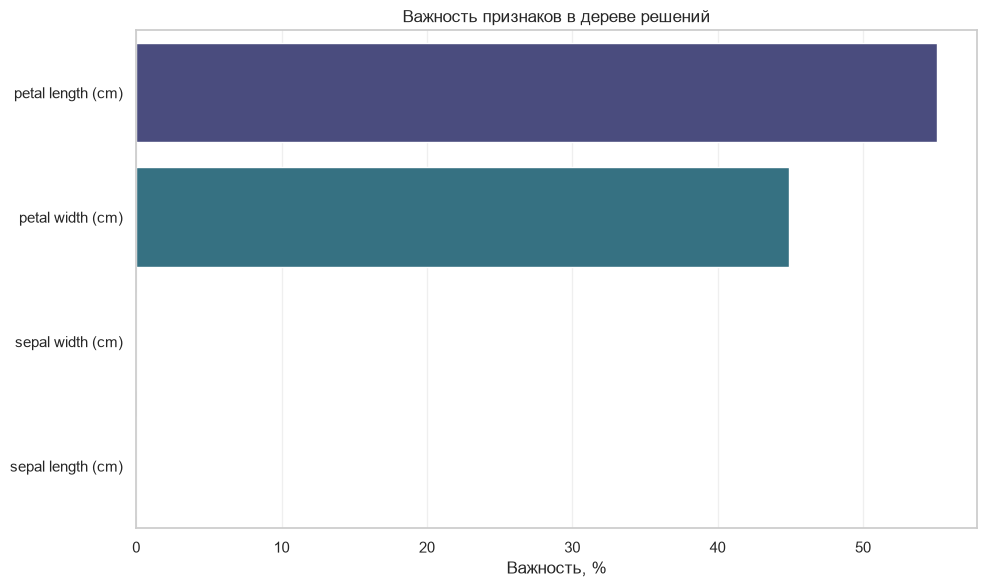

In [26]:
# Нарисуем важность признаков столбиками — так нагляднее.
fig, ax = plt.subplots(figsize=(10, 6))

# Рисуем горизонтальные столбики.
sns.barplot(
    data=importance_df,
    x="Важность, %",
    y="Признак",
    hue="Признак",
    palette="viridis",
    legend=False,
    ax=ax,
)

# Подписываем заголовок и ось X.
ax.set_title("Важность признаков в дереве решений")
ax.set_xlabel("Важность, %")
ax.set_ylabel("")

# Добавляем вертикальную сетку по оси X.
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

**Вывод:** признаки лепестка (petal length, petal width) забирают
**всю** важность — вместе 100 %. Длина лепестка весит около 55 %,
ширина — около 45 %. Признаки чашелистика получают ровно 0 %:
дерево ни разу не использовало их для разделения видов.

Это **полностью совпадает** с тем, что мы видели на графиках
"ящиков с усами" и на диаграммах рассеяния в пунктах 4.4–4.5.
Модель самостоятельно пришла к тому же выводу, что и наш
визуальный анализ, — и это хороший признак того, что она работает разумно.

**Практический вывод:** из четырёх признаков можно **без потери качества
оставить два** — длину и ширину лепестка. Более того, для этого датасета
дерево с ограничением в 5 листьев дало тот же результат на тесте (0.9778),
что и дерево без ограничений, но при этом проще и объяснимее.

## 7. Эксперименты в MLflow

**MLflow** ведёт журнал экспериментов: сохраняет параметры модели,
метрики и саму модель. Это позволяет сравнивать разные варианты
и не терять результаты.

Сравним три варианта дерева:

1. **Без ограничения глубины** — чтобы зафиксировать переобучение.
2. **С лучшей глубиной** — найденной перебором в пункте 5.3.
3. **С ограничением по числу листьев** — другой способ регуляризации.

In [27]:
# Настраиваем MLflow. Используем базу данных SQLite как хранилище.
mlflow.set_tracking_uri("sqlite:///mlflow.db")

# Имя эксперимента — все запуски ниже попадут сюда.
mlflow.set_experiment("Iris_DecisionTree")

print("MLflow настроен.")
print("Хранилище экспериментов: mlflow.db")
print("Имя эксперимента: Iris_DecisionTree")

MLflow настроен.
Хранилище экспериментов: mlflow.db
Имя эксперимента: Iris_DecisionTree


In [28]:
# Функция для запуска одного эксперимента в MLflow.
def run_tree_experiment(run_name, description, **tree_params):
    """Обучает дерево с заданными параметрами, логирует всё в MLflow
    и возвращает словарь с результатами.

    Все дополнительные именованные аргументы передаются напрямую
    в DecisionTreeClassifier. Так функция остаётся гибкой: можно передать
    max_depth, max_leaf_nodes или любой другой параметр модели.
    """

    # Открываем запуск в MLflow. Оператор with закроет его автоматически.
    with mlflow.start_run(run_name=run_name):

        # Создаём дерево с переданными параметрами.
        # Две звёздочки перед tree_params "раскрывают" словарь
        # в набор именованных аргументов.
        tree = DecisionTreeClassifier(random_state=RANDOM_STATE, **tree_params)

        # Обучаем дерево.
        tree.fit(X_train, y_train)

        # Считаем точность на обучении и на тесте.
        train_acc = tree.score(X_train, y_train)
        test_acc = tree.score(X_test, y_test)

        # Записываем параметры запуска в MLflow.
        mlflow.log_param("model_type", "DecisionTreeClassifier")
        mlflow.log_param("random_state", RANDOM_STATE)

        # Записываем переданные параметры дерева.
        # Если значение не задано, пишем "None" — то есть без ограничения.
        mlflow.log_param("max_depth", tree_params.get("max_depth", "None"))
        mlflow.log_param("max_leaf_nodes", tree_params.get("max_leaf_nodes", "None"))

        # Записываем описание эксперимента.
        mlflow.log_param("description", description)

        # Записываем метрики.
        mlflow.log_metric("accuracy_train", train_acc)
        mlflow.log_metric("accuracy_test", test_acc)

        # Считаем разрыв между обучением и тестом — это мера переобучения.
        mlflow.log_metric("overfit_gap", train_acc - test_acc)

        # Записываем фактическую сложность получившегося дерева.
        mlflow.log_metric("tree_depth", tree.get_depth())
        mlflow.log_metric("n_leaves", tree.get_n_leaves())

        # Сохраняем модель в MLflow.
        # serialization_format="cloudpickle" указывает формат сохранения.
        # Дело в том, что MLflow по умолчанию использует формат skops,
        # а он отказывается сохранять деревья решений, считая их
        # потенциально опасными при загрузке. cloudpickle лишён этого ограничения
        # и является стандартным форматом для моделей scikit-learn.
        mlflow.sklearn.log_model(
            tree,
            name="model",
            serialization_format="cloudpickle",
        )

        # Печатаем результат эксперимента.
        print(f"--- {run_name} ---")
        print(f"    Параметры: {tree_params if tree_params else 'без ограничений'}")
        print(f"    Accuracy на обучении : {train_acc:.4f}")
        print(f"    Accuracy на тесте    : {test_acc:.4f}")
        print(f"    Глубина дерева       : {tree.get_depth()}")
        print(f"    Листьев              : {tree.get_n_leaves()}")
        print()

        # Возвращаем результаты для итогового сравнения.
        return {
            "Запуск": run_name,
            "Accuracy обучение": round(train_acc, 4),
            "Accuracy тест": round(test_acc, 4),
            "Глубина": tree.get_depth(),
            "Листьев": tree.get_n_leaves(),
        }


print("Функция эксперимента готова.")

Функция эксперимента готова.


In [29]:
# Проводим три эксперимента и складываем результаты в список.
tree_results = []

# Эксперимент 1: дерево без ограничений — демонстрация переобучения.
tree_results.append(run_tree_experiment(
    run_name="full_tree_no_limit",
    description="Дерево без ограничения глубины: демонстрация переобучения",
))

# Эксперимент 2: дерево с лучшей глубиной, найденной перебором.
tree_results.append(run_tree_experiment(
    run_name=f"tree_max_depth_{best_depth}",
    description="Дерево с оптимальной глубиной, найденной перебором",
    max_depth=best_depth,
))

# Эксперимент 3: ограничение по числу листьев.
# Это другой способ регуляризации: мы говорим дереву,
# сколько максимум итоговых правил оно может выучить.
tree_results.append(run_tree_experiment(
    run_name="tree_max_leaf_nodes_5",
    description="Дерево с ограничением в 5 листьев",
    max_leaf_nodes=5,
))

print("Все три эксперимента выполнены.")

2026/09/25 13:39:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/09/25 13:39:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


--- full_tree_no_limit ---
    Параметры: без ограничений
    Accuracy на обучении : 1.0000
    Accuracy на тесте    : 0.9333
    Глубина дерева       : 5
    Листьев              : 8



2026/09/25 13:39:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


--- tree_max_depth_3 ---
    Параметры: {'max_depth': 3}
    Accuracy на обучении : 0.9810
    Accuracy на тесте    : 0.9778
    Глубина дерева       : 3
    Листьев              : 5



--- tree_max_leaf_nodes_5 ---
    Параметры: {'max_leaf_nodes': 5}
    Accuracy на обучении : 0.9810
    Accuracy на тесте    : 0.9778
    Глубина дерева       : 3
    Листьев              : 5

Все три эксперимента выполнены.


In [30]:
# Собираем результаты в таблицу.
tree_results_df = pd.DataFrame(tree_results)

print("Сравнение экспериментов с деревом решений:")
tree_results_df.reset_index(drop=True)

Сравнение экспериментов с деревом решений:


,Запуск,Accuracy обучение,Accuracy тест,Глубина,Листьев
0,full_tree_no_limit,1.000,0.9333,5,8
1,tree_max_depth_3,0.981,0.9778,3,5
2,tree_max_leaf_nodes_5,0.981,0.9778,3,5


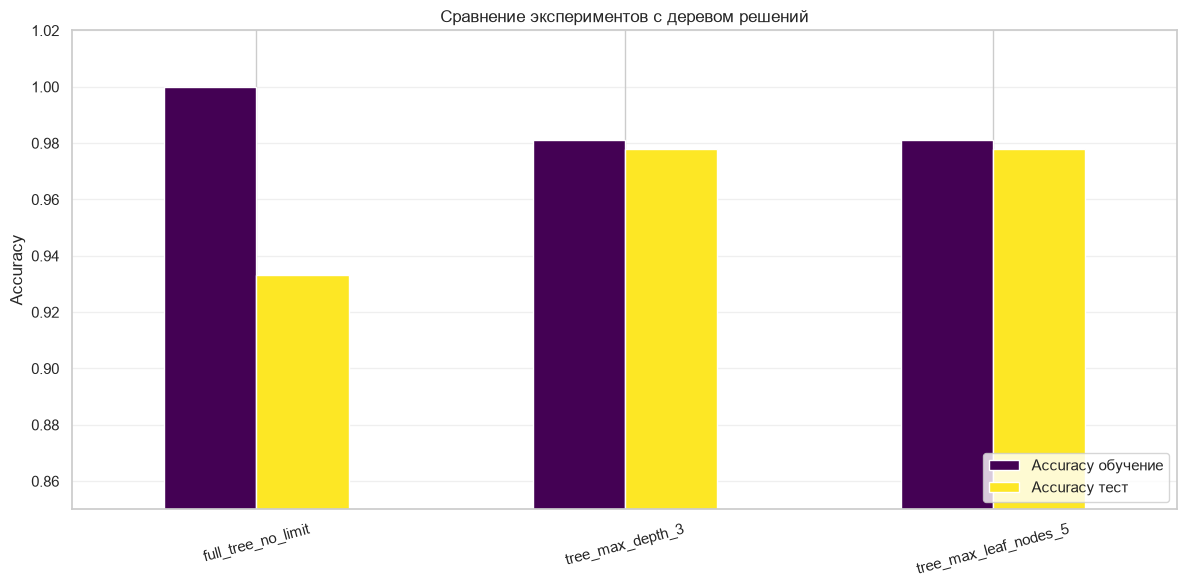

In [31]:
# Нарисуем сравнение: качество на обучении и на тесте для каждого варианта.

# Готовим данные для графика.
plot_data = tree_results_df.set_index("Запуск")[["Accuracy обучение", "Accuracy тест"]]

# Рисуем сгруппированную столбчатую диаграмму.
ax = plot_data.plot(
    kind="bar",
    figsize=(12, 6),
    ylim=(0.85, 1.02),   # диапазон оси Y (все значения близки к 1)
    rot=15,              # небольшой наклон подписей
    colormap="viridis",
)

ax.set_title("Сравнение экспериментов с деревом решений")
ax.set_ylabel("Accuracy")
ax.set_xlabel("")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Что показало сравнение

* **Дерево без ограничений** даёт идеальное качество на обучении (1.0).
  Это первый признак переобучения: модель запомнила данные.
  На тесте результат ниже — именно этот разрыв и есть цена переобучения.
* **Дерево с оптимальной глубиной** показывает лучший результат
  на тестовой выборке. Оно проигрывает на обучении, но выигрывает там,
  где это важно — на новых данных.
* **Дерево с 5 листьями** самое простое. Оно может дать результат
  чуть ниже, зато его правила легко объяснить: всего пять условий.

**Главный вывод:** "идеальный результат на обучении" — это не достижение,
а тревожный сигнал. Настоящая цель модели — хороший результат
на данных, которых она никогда не видела.

### Как посмотреть результаты MLflow

MLflow сохраняет всё в файл **mlflow.db** рядом с ноутбуком.
Чтобы открыть веб-интерфейс и увидеть сравнение запусков:

    mlflow ui --backend-store-uri sqlite:///mlflow.db

Затем откройте http://127.0.0.1:5000 — там будут все три запуска
с параметрами, метриками и сохранёнными моделями.

## 8. Выводы

**Что сделано:**

1. Загружен и описан датасет Iris: 150 цветков, 4 признака, 3 вида.
2. Проведён разведочный анализ: пропусков нет, классы сбалансированы
   по 50 образцов. Найдены дубликаты по измерениям,
   но противоречий между ними нет.
3. Построены "ящики с усами", гистограммы и диаграммы рассеяния.
   Обнаружено, что признаки лепестка разделяют виды почти идеально,
   а признаки чашелистика — плохо.
4. Построена матрица корреляции: petal length ↔ petal width связаны
   с корреляцией около +0.96.
5. Проведён явный эксперимент по переобучению: сравнено дерево
   без ограничений и деревья с ограниченной глубиной.
6. Найдена оптимальная глубина перебором от 1 до 10.
7. Построено дерево решений, нарисована его структура,
   проанализирована важность признаков.
8. Проведены три эксперимента в MLflow и выполнено их сравнение.

**Ключевой результат:** дерево решений с ограниченной глубиной
показывает очень высокую точность на тестовой выборке.
Единственные возможные ошибки — путаница между versicolor и virginica,
самыми близкими видами.

**Чему учит эта задача:**

* **Переобучение — главный враг дерева решений.** Без ограничения
  глубины дерево вырастает до такой степени, что запоминает
  обучающие примеры наизусть. Ограничение глубины — обязательный шаг.
* **Смотреть надо на тест, а не на обучение.** Модель, идеальная
  на обучении, часто бесполезна на новых данных.
* **Дерево объяснимо.** Его можно нарисовать и показать человеку —
  в отличие от нейронной сети. Это огромное преимущество
  в задачах, где важно объяснить решение.
* **Дереву не нужно масштабирование.** Оно сравнивает признаки
  с порогами, поэтому единицы измерения не важны.
* **Визуальный анализ и модель согласуются.** Важность признаков,
  которую посчитало дерево, совпала с тем, что мы увидели на графиках.
  Это хороший способ проверить, что модель работает разумно.

**Что можно улучшить:**

* перейти к **случайному лесу** — объединению множества деревьев,
  которое борется с переобучением гораздо эффективнее;
* применить **кросс-валидацию** вместо одного разделения на обучение и тест:
  она даёт более надёжную оценку качества;
* провести **отбор признаков** и оставить только признаки лепестка;
* построить **границу принятия решений** — график, показывающий,
  как именно модель делит пространство признаков между классами.